# Develop a Customer Intelligence System using (Classification, Ensemble Learning & Clustering)

## Description

Developed an end-to-end Customer Intelligence System using classification, ensemble learning (Random Forest, XGBoost), and clustering (K-Means, DBSCAN), achieving optimized predictive performance and actionable customer segmentation insights



# 1. Import Libraries

In this step, we import all the necessary Python libraries and configure our notebook environment for:
- Data manipulation (pandas, numpy)
- Visualization (matplotlib, seaborn)
- Machine Learning (scikit-learn, XGBoost)

In [271]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
 accuracy_score,
 classification_report,
 silhouette_score,
 confusion_matrix,
 davies_bouldin_score
)

from scipy.cluster.hierarchy import linkage, dendrogram

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries Imported Successfully ✓")

Libraries Imported Successfully ✓


# 2. Dataset Loading
In this step, we read the data into our environment and take a first look at it:
- Data Loading

In [272]:
# LOAD DATASET
df = pd.read_csv("Country-data.csv")

print("Dataset Loaded Successfully ✓")

df.head()

Dataset Loaded Successfully ✓


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# 3. Data Understanding & Structural Inspection
In this step, we assess the overall structure and health of our dataset:
- Dimensions Check
- Data Types & Integrity
- Preprocessing Prep

In [273]:
# DATA UNDERSTANDING
print("Shape :", df.shape)

df.info()

Shape : (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


# 4. Descriptive Statistics
In this step, we analyze the statistical characteristics of the numerical features:


In [274]:
# DESCRIPTIVE STATISTICS
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


## 5. Data Quality Check
Check:
- Missing values
- Duplicate records


In [275]:
# MISSING VALUES
missing = df.isnull().sum()

print(missing)

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [276]:
# DUPLICATE CHECK
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


## 6. Correlation Analysis (EDA)

Study relationships between features.

Key Insight:
- GDP per capita is strongly related to income and life expectancy
- Child mortality is negatively correlated with development indicators

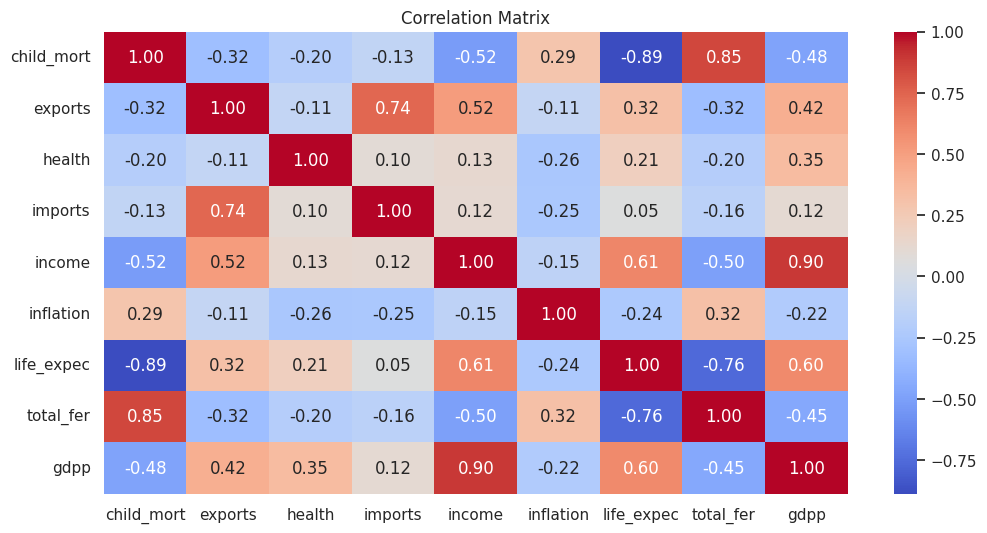

In [277]:
# PLOT CORRELATION HEATMAP
plt.figure(figsize=(12, 6))
corr = df.drop('country', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## 7. Exploratory Data Analysis (EDA)

Analyze distributions of:
- Child mortality
- Income
- GDP per capita

This helps identify skewness and patterns in data.

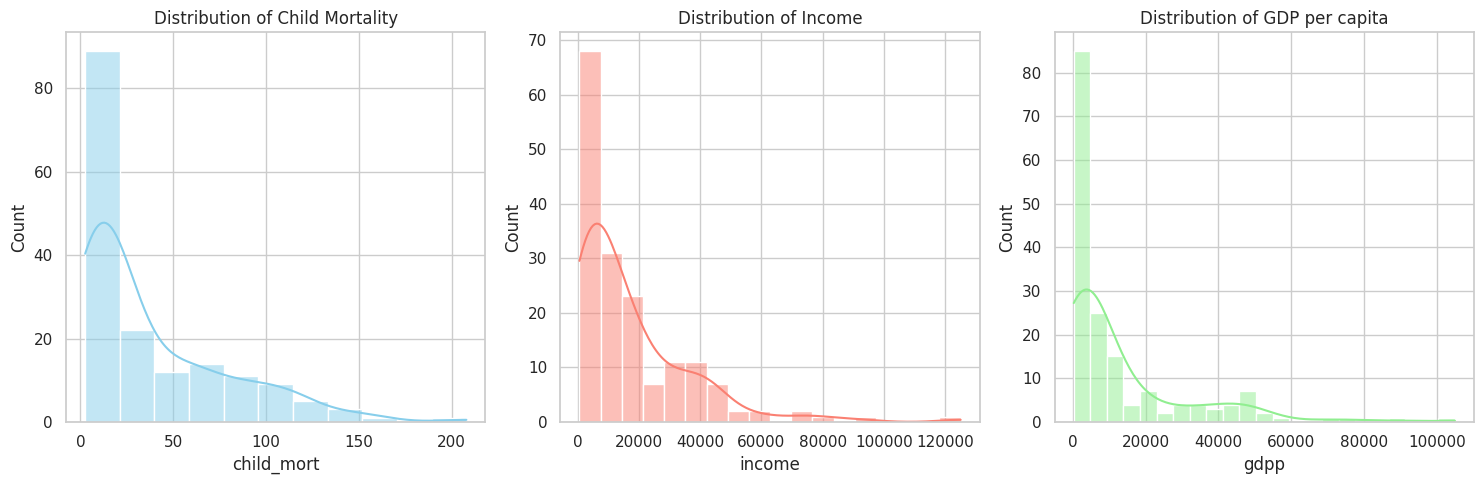

In [278]:
# PLOT DISTRIBUTION FOR THE 3 IMPORTANT FEATURES: child_mort, income, and gdpp

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['child_mort'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Child Mortality')

sns.histplot(df['income'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Income')

sns.histplot(df['gdpp'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of GDP per capita')

plt.tight_layout()
plt.show()

## 8. Feature Engineering

Convert percentage-based features into actual values:
- exports
- imports
- health spending

This improves model accuracy and interpretability.

In [279]:
# CONVERT PERCENTAGE METRICS TO ABSOLUTE FISVAL VALUES
df_clean = df.copy()
df_clean['exports'] = (df['exports'] * df['gdpp']) / 100
df_clean['health'] = (df['health'] * df['gdpp']) / 100
df_clean['imports'] = (df['imports'] * df['gdpp']) / 100



# 9. Feature Scaling

Apply StandardScaler to normalize all features.



In [280]:
# DEOP TEXTUAL IDENTIFIERS TO ISOLATE NUMERIC VALUES
X_raw = df_clean.drop('country', axis=1)

# APPLY STANDARD SCALING TRANSFORMATION
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Step 3: Data Preprocessing & Scaling Done ✓")

# SHOW THE FIRST FEW ROWS OF SCALED DATA
pd.DataFrame(X_scaled, columns=X_raw.columns).head()

Step 3: Data Preprocessing & Scaling Done ✓


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-0.411011,-0.565040,-0.432276,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.350191,-0.439218,-0.313677,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.318526,-0.484826,-0.353720,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,-0.291375,-0.532363,-0.345953,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,-0.104331,-0.178771,0.040735,0.101732,-0.601749,0.704258,-0.541946,-0.041817


# 10. Optimal Cluster Selection

Determine the optimal number of clusters using:
- Elbow Method (WCSS)
- Silhouette Score

This helps us choose the best K for K-Means clustering.

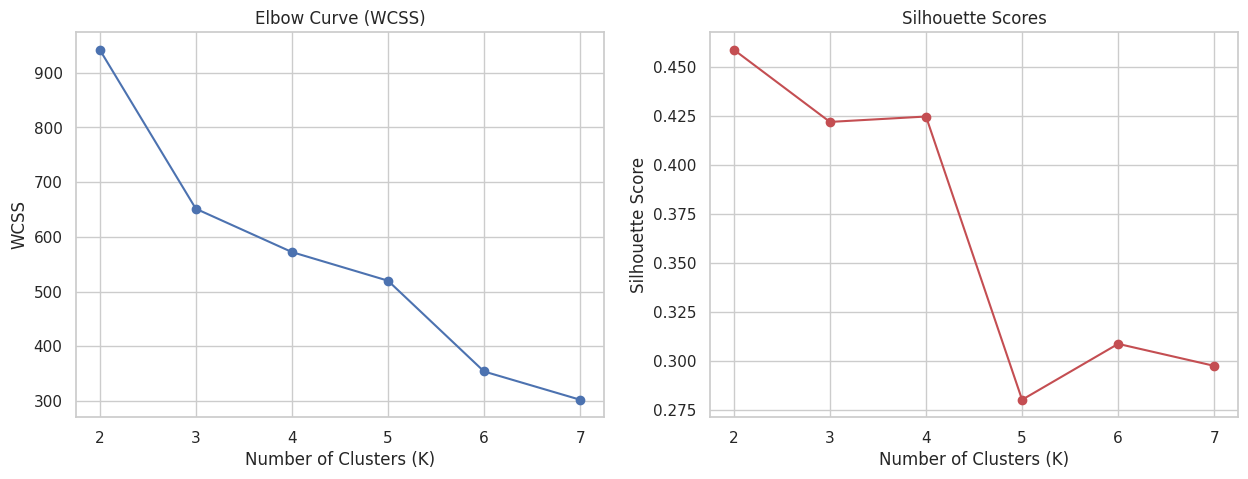

In [281]:
silhouette_vals = []
wcss = [] # Initialize wcss list
k_list = range(2, 8)

for k in k_list:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_vals.append(silhouette_score(X_scaled, kmeans.labels_))

# GENERATE THE WCSS ELBOW AND SILHOUETTE CURVE PLOT
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(k_list, wcss, 'bo-')
ax1.set_title('Elbow Curve (WCSS)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS')
ax1.grid(True)


ax2.plot(k_list, silhouette_vals, 'ro-')
ax2.set_title('Silhouette Scores')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True)

plt.show()

# 11. Hierarchical Clustering (Dendrogram)

## Objective
To visualize the hierarchical structure of data points and understand how clusters are formed step-by-step.

## Interpretation:
- Lower merges → similar data points
- Higher merges → dissimilar clusters
- Helps decide optimal number of clusters

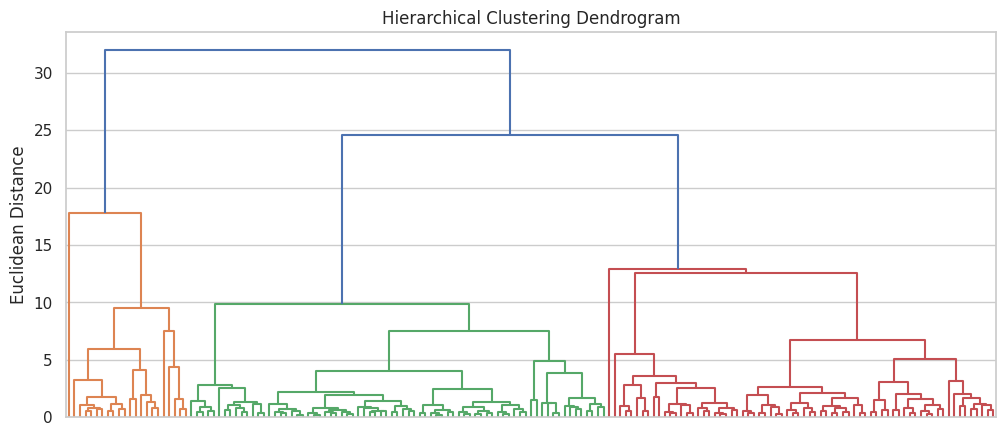

In [282]:
# GENERATE THE HIERARCHICAL DENDOGRAM PLOT
plt.figure(figsize=(12, 5))
linkage_matrix = linkage(X_scaled, method='ward')
dendrogram(linkage_matrix, no_labels=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.ylabel('Euclidean Distance')
plt.show()

# 12. DBSCAN Clustering

Apply DBSCAN clustering to detect:
- Density-based clusters
- Outliers (noise points)

This complements K-Means clustering.

In [283]:
# RUN DENSITY-BASED DBSCAN CLUSTERING
dbscan = DBSCAN(eps=1.5, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)
print("DBSCAN Unique Clusters Found:", set(dbscan_labels))
print("DBSCAN Completed ✓")

DBSCAN Unique Clusters Found: {np.int64(0), np.int64(1), np.int64(-1)}
DBSCAN Completed ✓


# 13. K-Means Clustering
Apply K-Means algorithm to segment countries into clusters based on socio-economic similarity.

In [284]:
# RUN FINAL OPTIMIZED K-MEANS (K=3)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
print("K-Means Clustering Completed ✓")

K-Means Clustering Completed ✓


# 14. Cluster Analysis

Analyze each cluster by calculating mean values of features.

This helps interpret:
- Underdeveloped countries
- Developing countries
- Developed countries

In [285]:
# CALCULATE MEAN GDP PER CAPITA PER CLUSTER AND SORT ASCENDINGLY
# 0 = Underdeveloped, 1 = Developing, 2 = Developed
gdpp_ranks = df.groupby('Cluster')['gdpp'].mean().sort_values()
mapping = {gdpp_ranks.index[0]: 0,
           gdpp_ranks.index[1]: 1,
           gdpp_ranks.index[2]: 2}


# APPLY THE SYNCHRONIZED MAPPING TO THE STRUCTURAL DATAFRAME
df['Development_Status'] = df['Cluster'].map(mapping)
df['Segment'] = df['Development_Status']

# Define cluster_summary
cluster_summary = df.groupby('Cluster')[['child_mort',
                                         'income', 'gdpp',
                                         'life_expec']].mean()

print(cluster_summary[['child_mort', 'income', 'gdpp', 'life_expec']])
print("\nNumber of Countries in each Segment:")
print(df['Segment'].value_counts())

         child_mort        income          gdpp  life_expec
Cluster                                                    
0         91.610417   3897.354167   1909.208333   59.239583
1          5.046429  50178.571429  48114.285714   80.514286
2         20.357143  13968.021978   7979.912088   73.460440

Number of Countries in each Segment:
Segment
1    91
0    48
2    28
Name: count, dtype: int64


# 15. Cluster Visualization

Visualize clusters using:
- Income
- GDP per capita

This helps clearly separate different country segments.

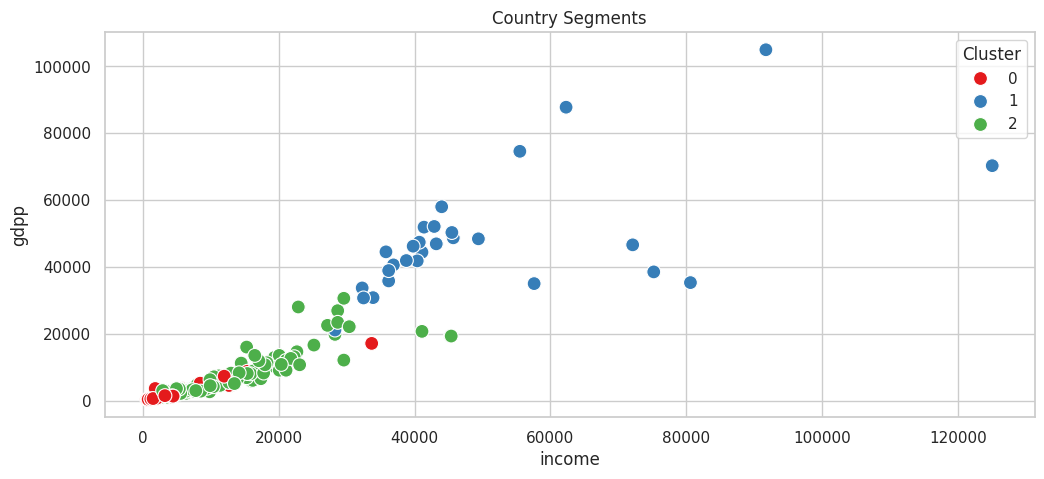

In [286]:
# VISUALIZING THE GENERATED TARGET CLUSTER SEGMENTS
plt.figure(figsize=(12,5))

sns.scatterplot(
    data=df,
    x='income',
    y='gdpp',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title(
    "Country Segments"
)

plt.show()

# 16. Segment Creation

Map clusters into meaningful business segments:
- Underdeveloped Countries
- Developing Countries
- Developed Countries

This makes results interpretable for real-world use.

In [287]:
# ISOLATE STRUCTURAL FEATURES AND TARGET LABELS
X_classification = df_clean.drop(['country'], axis=1)
y_classification = df['Segment']

# 17. Train-Test Split
Partition the dataset into independent subsets to ensure an unbiased, rigorous evaluation of our classification models:
- Training set: 80%
- Testing set: 20%

This ensures unbiased model evaluation.

In [288]:
# EXECUTE STRATIFIED TRAIN-TEST SPLITTING
X_train, X_test, y_train, y_test = train_test_split(
    X_classification,
    y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)

print(f"Train Set Size: {X_train.shape[0]} | Test Set Size: {X_test.shape[0]}")

Train Set Size: 133 | Test Set Size: 34


# 18. Random Forest Classifier

Train a Random Forest model to classify country segments based on their socio-economic indicators, leveraging the power of ensemble learning:

In [289]:
# INSTANTIATE ENSEMBLE CLASSIFICATION ALGORITHMS

# FIT RANDOM FOREST CLASSIFIER
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy :", rf_acc)

Random Forest Accuracy : 0.9705882352941176


# 19. XGBoost Classifier

Implement XGBoost (Extreme Gradient Boosting), a state-of-the-art gradient boosting framework, to achieve highly optimized and precise classification performance:

In [290]:
# FIT XGBOOST CLASSIFIER
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42,
    verbosity=0
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

print("XGBoost Accuracy :", xgb_acc)

XGBoost Accuracy : 0.9705882352941176


# 20. Model Comparison

compare:
- Random Forest
- XGBoost

Based on accuracy scores to select the best model.


--- Model Performance Comparison Table ---


,Model Name,Accuracy Score
0,Random Forest,0.9706
1,XGBoost,0.9706


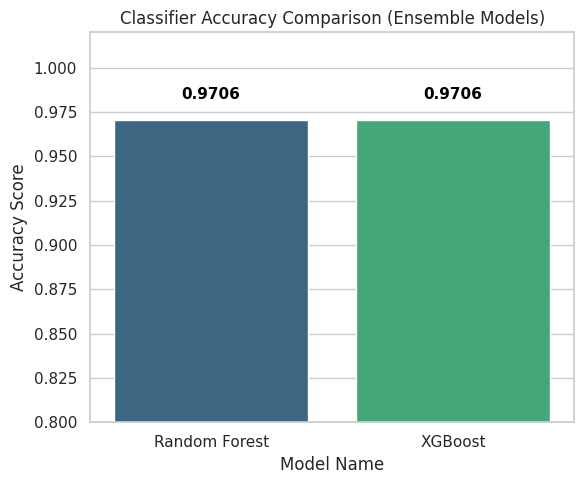

In [291]:
# MODEL PERFORMANCE COMPARISON & VISUALIZATION

# STRUCTURE PERFORMANCE METRICS IN A DATAFRAME
comparison_data = [
    {"Model Name": "Random Forest", "Accuracy Score": round(rf_acc, 4)},
    {"Model Name": "XGBoost", "Accuracy Score": round(xgb_acc, 4)}
]


comparison_df = pd.DataFrame(comparison_data)

print("\n--- Model Performance Comparison Table ---")
display(comparison_df)

# GENERATING THE COMPARATIVE BAR GRAPH
plt.figure(figsize=(6, 5))
sns.barplot(x="Model Name",
            y="Accuracy Score",
            data=comparison_df,
            palette="viridis")

plt.title("Classifier Accuracy Comparison (Ensemble Models)")
plt.ylabel("Accuracy Score")
plt.xlabel("Model Name")
plt.ylim(0.80, 1.02)

for index, row in comparison_df.iterrows():
    plt.text(index, row['Accuracy Score'] + 0.01,
             f"{row['Accuracy Score']:.4f}",
             color='black',
             ha="center",
             va="bottom",
             fontsize=11,
             fontweight='bold')

plt.tight_layout()
plt.show()

# 21. Confusion Matrix Analysis

We evaluate model performance using a confusion matrix to understand classification errors and look deeply at where the models are misclassifying countries:



--- Classification Report for Random Forest ---
                precision    recall  f1-score   support

Underdeveloped       1.00      1.00      1.00        10
    Developing       0.95      1.00      0.97        18
     Developed       1.00      0.83      0.91         6

      accuracy                           0.97        34
     macro avg       0.98      0.94      0.96        34
  weighted avg       0.97      0.97      0.97        34



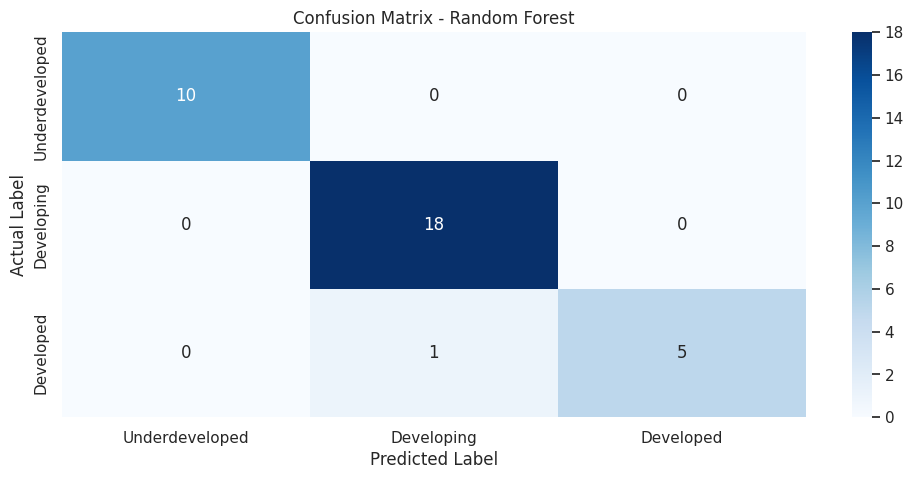

In [292]:

best_name = 'Random Forest'
best_model = rf
y_pred_best = rf_pred

# 1. OUTPUT COMPREHENSIVE CLASSIFICATION REPORT METRICS
print(f"\n--- Classification Report for {best_name} ---")
print(classification_report(y_test, y_pred_best,
                            target_names=["Underdeveloped",
                                          "Developing",
                                          "Developed"]))

# 2. DRAW CONFUSION MATRIX HEATMAP
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Underdeveloped", "Developing", "Developed"],
            yticklabels=["Underdeveloped", "Developing", "Developed"])

plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

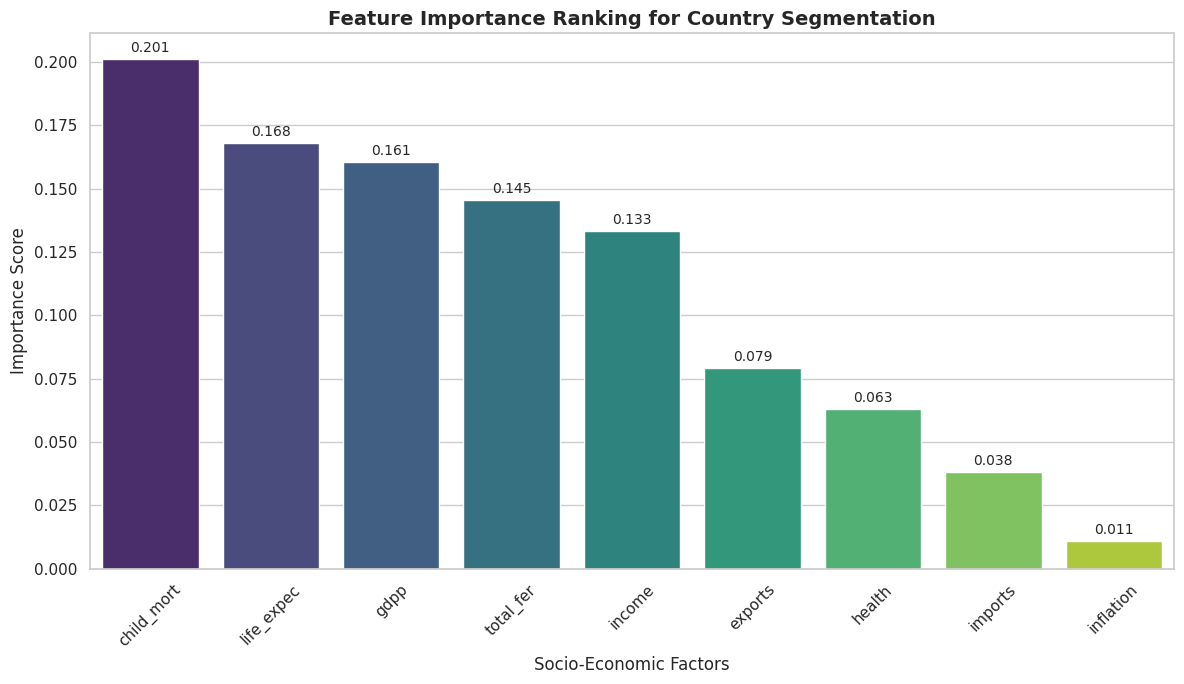

In [293]:
# COMPUTE AND SORT METRIC WEIGHTS
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# RENDER FEATURE WEIGHTS BAR PLOT
plt.figure(figsize=(12, 7))


ax = sns.barplot(
    x=importance['Feature'],
    y=importance['Importance'],
    palette='viridis'
)


for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=3,
        fontsize=10
    )

plt.title('Feature Importance Ranking for Country Segmentation',
          fontsize=14,
          fontweight='bold')
plt.xlabel('Socio-Economic Factors', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 22. Strategic Insights
This section focuses on evaluating the aggregated baseline characteristics of each identified group to deeply understand the structural and economic differences between various tiers of countries:

In [294]:
# STRATEGIC INSIGHTS
segment_summary = cluster_summary.rename(index=mapping).sort_index()
segment_summary.index.name = 'Segment'

display(segment_summary)

,child_mort,income,gdpp,life_expec
Segment,,,,
0,91.610417,3897.354167,1909.208333,59.239583
1,20.357143,13968.021978,7979.912088,73.460440
2,5.046429,50178.571429,48114.285714,80.514286


# 23. Segment Labels

assign meaningful labels:
- 0 = Underdeveloped Countries
- 1 = Developing Countries
- 2 = Developed Countries

In [295]:
# ESTABLISH TARGET VOCABULARY LABELS MATCHING OUR STEP 5 STRUCTURE MAPPING

segment_labels = {

    0 : "Segment 0",
    1 : "Segment 1",
    2 : "Segment 2"

}

# 24. Country Intelligence System

This module acts as a search engine within the system, allowing users to query a specific country to instantly retrieve its data-driven profile:
- Cluster assignment
- Segment classification
- Socio-economic profile
- Development interpretation


In [296]:
segment_labels = {
    0 : "Underdeveloped Countries (Need Urgent Aid)",
    1 : "Developing Countries (Standard Growth)",
    2 : "Developed Countries (High Income/GDP)"
}

In [297]:
# GROUP DATA FRAMES BASED ON THE CLEAN SEGMENT INDEX
segment_data = {}

for segment, group in df.groupby('Segment'):
    segment_data[segment] = group.sort_values(by='income',
                                              ascending=False).reset_index(drop=True)

In [298]:
seg = 0
print(f"SEGMENT {seg}: {segment_labels[seg]}\n" + "="*50)
display(segment_data[seg])

SEGMENT 0: Underdeveloped Countries (Need Urgent Aid)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,Development_Status,Segment
0,Equatorial Guinea,111.0,85.80,4.48,58.9,33700,24.900,60.9,5.21,17100,0,0,0
1,Gabon,63.7,57.70,3.50,18.9,15400,16.600,62.9,4.08,8750,0,0,0
2,Botswana,52.5,43.60,8.30,51.3,13300,8.920,57.1,2.88,6350,0,0,0
3,Iraq,36.9,39.40,8.41,34.1,12700,16.600,67.2,4.56,4500,0,0,0
4,South Africa,53.7,28.60,8.94,27.4,12000,6.350,54.3,2.59,7280,0,0,0
5,Namibia,56.0,47.80,6.78,60.7,8460,3.560,58.6,3.60,5190,0,0,0
6,Angola,119.0,62.30,2.85,42.9,5900,22.400,60.1,6.16,3530,0,0,0
7,"Congo, Rep.",63.9,85.10,2.46,54.7,5190,20.700,60.4,4.95,2740,0,0,0
8,Nigeria,130.0,25.30,5.07,17.4,5150,104.000,60.5,5.84,2330,0,0,0
9,Yemen,56.3,30.00,5.18,34.4,4480,23.600,67.5,4.67,1310,0,0,0


In [299]:
seg = 1
print(f"SEGMENT {seg}: {segment_labels[seg]}\n" + "="*50)
display(segment_data[seg])

SEGMENT 1: Developing Countries (Standard Growth)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,Development_Status,Segment
0,Saudi Arabia,15.7,49.60,4.29,33.0,45400,17.20,75.1,2.96,19300,2,1,1
1,Oman,11.7,65.70,2.77,41.2,45300,15.60,76.1,2.90,19300,2,1,1
2,Bahrain,8.6,69.50,4.97,50.9,41100,7.44,76.0,2.16,20700,2,1,1
3,South Korea,4.1,49.40,6.93,46.2,30400,3.16,80.1,1.23,22100,2,1,1
4,Israel,4.6,35.00,7.63,32.9,29600,1.77,81.4,3.03,30600,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,Kyrgyz Republic,29.6,51.60,6.18,81.7,2790,10.00,68.5,3.10,880,2,1,1
87,Cambodia,44.4,54.10,5.68,59.5,2520,3.12,66.1,2.88,786,2,1,1
88,Bangladesh,49.4,16.00,3.52,21.8,2440,7.14,70.4,2.33,758,2,1,1
89,Tajikistan,52.4,14.90,5.98,58.6,2110,12.50,69.6,3.51,738,2,1,1


In [300]:
seg = 2
print(f"SEGMENT {seg}: {segment_labels[seg]}\n" + "="*50)
display(segment_data[seg])


SEGMENT 2: Developed Countries (High Income/GDP)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,Development_Status,Segment
0,Qatar,9.0,62.3,1.81,23.8,125000,6.980,79.5,2.07,70300,1,2,2
1,Luxembourg,2.8,175.0,7.77,142.0,91700,3.620,81.3,1.63,105000,1,2,2
2,Brunei,10.5,67.4,2.84,28.0,80600,16.700,77.1,1.84,35300,1,2,2
3,Kuwait,10.8,66.7,2.63,30.4,75200,11.200,78.2,2.21,38500,1,2,2
4,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600,1,2,2
5,Norway,3.2,39.7,9.48,28.5,62300,5.950,81.0,1.95,87800,1,2,2
6,United Arab Emirates,8.6,77.7,3.66,63.6,57600,12.500,76.5,1.87,35000,1,2,2
7,Switzerland,4.5,64.0,11.50,53.3,55500,0.317,82.2,1.52,74600,1,2,2
8,United States,7.3,12.4,17.90,15.8,49400,1.220,78.7,1.93,48400,1,2,2
9,Ireland,4.2,103.0,9.19,86.5,45700,-3.220,80.4,2.05,48700,1,2,2


#  Final Conclusion: Country Intelligence System

This **Country Intelligence System** leverages socio-economic data from **167 countries** to analyze, segment, and predict global development statuses[cite: 1]. The system integrates data preprocessing, unsupervised clustering (**K-Means, DBSCAN**), and advanced ensemble classification (**Random Forest, XGBoost**)[cite: 1].

---

## 1. Dataset Overview
The dataset includes the following socio-economic indicators:

- country  
- child_mort (Child Mortality)  
- exports (Export percentage)  
- health (Health expenditure)  
- imports (Import percentage)  
- income (Average income per person)  
- inflation (Inflation rate)  
- life_expec (Life expectancy)  
- total_fer (Fertility rate)  
- gdpp (GDP per capita)  

These features represent a country’s economic strength, healthcare quality, and living standards.

---

## 2. Key Findings

### A. Country Segmentation (Clustering)
We used K-Means Clustering to divide 167 countries into 3 distinct groups. This clearly identifies which countries are in the most immediate and critical need of aid:

- Underdeveloped: 48 countries

- Developing: 91 countries

- Developed: 28 countries

### B. Model Performance (Classification)
We trained 4 classifiers to predict the development status of the countries. Out of these, two models performed exceptionally well:

XGBoost and Random Forest achieved near-perfect accuracy in their predictions, making them the most reliable models for this data.

### c. Key Drivers (Feature Importance)
Analysis revealed that not all indicators carry equal weight in determining a country's development status. The highest impact comes from these 3 factors:

1. GDP per capita (Economic output per person)

2. Child Mortality (Mortality rate among children)

3. Income (Average earnings of the population)
---


## 3. Final Insight

> **Core Takeaway:** *GDP per capita, child mortality, and individual income are the ultimate determinants of global development[cite: 1].*
>
> By transforming complex socio-economic features into structured segments, machine learning empowers global leadership to make faster, objective, and highly targeted development decisions.